# MEGASWEEP

### Imports

In [1]:
%%capture
%pip install numpy pandas statsmodels matplotlib itertools arch joblib scipy

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import itertools
import warnings
from arch import arch_model
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
np.random.seed(42)

### Inputs

In [3]:
# Global Configuration
N = 5000         # ~20 years of daily data
M = 2            # Keep low (1-2) for testing, raise to 10-20 for production
test_window = 1250 # ~5 years of out-of-sample backtesting
train_size = 500 # ~2 years rolling training (captures enough data, but forgets old regimes)

P_grids = [
    # Scenario A: Standard Macro Cycles (Both regimes are sticky)
    [[0.99, 0.01],   # Regime 0: 99% chance to stay (lasts ~100 days)
     [0.02, 0.98]],  # Regime 1: 98% chance to stay (lasts ~50 days)
    
    # Scenario B: "Flash Crach / Panic" (Regime 1 is violent and short-lived)
    [[0.995, 0.005], # Regime 0: Highly stable (lasts ~200 days)
     [0.15, 0.85]]   # Regime 1: High chance to exit back to quiet (lasts ~6 days)
]

mu_grids = [
    [0.0, 0.0],     # No drift (Pure volatility regimes)
    
    # Realistic Drift: Bull makes ~0.05% a day (12% annualized), 
    # Bear loses ~-0.20% a day (sharp drawdowns)
    [0.05, -0.20]   
]

sig_grids = [
    # Scenario A: Normal vs Crisis
    # Regime 0: ~12% annualized vol (VIX ~12)
    # Regime 1: ~40% annualized vol (VIX ~40 - like 2008 or 2020)
    [0.75, 2.50],   
    
    # Scenario B: Constant realistic volatility (Control group)
    # Both regimes sit at an average ~16% annualized vol
    [1.0, 1.0]      
]

phi = [0.03, -0.05]

### Scoring

In [4]:
def winkler(y, m, v, a=0.05):
    """Calculates the Winkler Score for interval forecasting."""
    d = 1.96 * np.sqrt(v)
    l, u = m - d, m + d
    return (u - l) + (2/a) * max(l - y, 0) + (2/a) * max(y - u, 0)

def analyze(y, p, v):
    """Calculates performance metrics for a prediction series."""
    y, p, v = np.array(y), np.array(p), np.array(v)
    s = np.sqrt(v)
    rets = np.sign(p) * y
    
    return [
        np.mean((y - p)**2),                            # MSE
        np.mean([winkler(yi, pi, vi) for yi, pi, vi in zip(y, p, v)]), # Winkler
        np.mean((y >= p - 1.96*s) & (y <= p + 1.96*s)), # Cov95
        np.mean(np.sign(y) == np.sign(p)),               # HitRate
        (np.mean(rets) / np.std(rets)) * np.sqrt(252) if np.std(rets) > 0 else 0, # Sharpe
        np.sum(rets)                                    # TotRet
    ]

### Processing

In [5]:
def process_step(tr, act, sweeps, is_last_step=False):
    step_results = {}
    failed_models = []
    step_params = {} # NEW: Dict to hold parameters
    
    for name, (m_type, val) in sweeps.items():
        try:
            if m_type == "ar":
                m = sm.tsa.AutoReg(tr, val).fit()
                step_results[name] = [m.predict(len(tr), len(tr))[0], m.sigma2]
                if is_last_step: step_params[name] = m.params.values
            
            elif m_type in ["arch", "garch"]:
                p, q = (val, 0) if m_type == "arch" else val
                m = arch_model(tr, vol='Garch', p=p, q=q).fit(disp='off')
                f = m.forecast(horizon=1)
                step_results[name] = [f.mean.values[-1,0], f.variance.values[-1,0]]
                if is_last_step: step_params[name] = m.params.values
            
            elif m_type == "ms":
                m = sm.tsa.MarkovAutoregression(tr, k_regimes=2, order=val, 
                                                switching_variance=True).fit(search_reps=20, disp=False)
                p_nxt = np.asarray(m.regime_transition).reshape(2,2) @ \
                        np.asarray(m.filtered_marginal_probabilities)[-1].flatten()
                lags = tr[-val:][::-1]
                mu_regimes = [m.params[2+r] + np.dot(m.params[4+r:4+2*val:2], lags) for r in range(2)]
                step_results[name] = [np.dot(p_nxt, mu_regimes), np.dot(p_nxt, m.params[-2:])]
                if is_last_step: step_params[name] = m.params.values
                
        except Exception:
            failed_models.append(name)
            
    return step_results, failed_models, step_params

### Sweep grid

In [6]:
scenarios = list(itertools.product(P_grids, mu_grids, sig_grids))

sweeps = {
    "AR(1)": ("ar", 1), 
    "GARCH(1,1)": ("garch", (1,1)), 
    "MSAR-O1": ("ms", 1) 
}

print(f"Grid defined. Total scenarios to test: {len(scenarios)}")

Grid defined. Total scenarios to test: 8


### Master execution

In [7]:
master_results = {}

for s_idx, (P, mu, sig) in enumerate(scenarios):
    s_name = f"S{s_idx}: P{P[0][0]}_M{mu[0]}_S{sig[0]}"
    print(f"\nProcessing {s_name}...")
    
    paths = []
    for _ in range(M):
        s, y = [0], [0.]
        for t in range(1, N):
            s.append(np.random.choice([0, 1], p=P[s[-1]]))
            y.append(mu[s[-1]] + phi[s[-1]] * y[-1] + np.random.normal(0, sig[s[-1]]))
        paths.append(np.array(y))
    
    all_results = {k: [] for k in sweeps}
    scenario_params = {k: [] for k in sweeps} # NEW: Track params for this scenario
    
    for p_idx, path in enumerate(paths):
        results = Parallel(n_jobs=-1)(
            # NEW: pass i == 1 to flag the last step
            delayed(process_step)(path[-i-train_size:-i], path[-i], sweeps, i == 1) 
            for i in range(test_window, 0, -1)
        )
        
        path_hist = {k: [] for k in sweeps}
        for step_res, fails, params in results:
            for name in sweeps:
                if name in step_res: path_hist[name].append(step_res[name])
                # NEW: If params were returned for this model, save them
                if name in params: scenario_params[name].append(params[name])
        
        for k in sweeps: all_results[k].append(path_hist[k])
    
    metrics = {}
    for mod in all_results:
        m_list = [analyze(paths[i][-test_window:], np.array(pv)[:,0], np.array(pv)[:,1]) 
                  for i, pv in enumerate(all_results[mod]) if len(pv) == test_window]
        if m_list: metrics[mod] = np.mean(m_list, axis=0)
    
    # NEW: Average the recovered params across all paths and store them
    avg_params = {mod: np.mean(scenario_params[mod], axis=0) for mod in sweeps if scenario_params[mod]}
    
    # Store both metrics and parameters
    master_results[s_name] = {
        "metrics": metrics,
        "true_dgp": {"P": P, "mu": mu, "sig": sig, "phi": phi},
        "est_params": avg_params
    }


Processing S0: P0.99_M0.0_S0.75...

Processing S1: P0.99_M0.0_S1.0...

Processing S2: P0.99_M0.05_S0.75...

Processing S3: P0.99_M0.05_S1.0...

Processing S4: P0.995_M0.0_S0.75...

Processing S5: P0.995_M0.0_S1.0...

Processing S6: P0.995_M0.05_S0.75...

Processing S7: P0.995_M0.05_S1.0...


### Analysis

In [8]:
headers = ["MSE", "Winkler", "Cov95", "HitRate", "Sharpe", "TotRet"]

for s_name, data in master_results.items():
    print(f"\n{'='*80}")
    print(f"SCENARIO: {s_name}")
    print(f"{'='*80}")
    
    # 1. Print True Parameters
    t_dgp = data["true_dgp"]
    print(f"TRUE DGP => P(0|0):{t_dgp['P'][0][0]}, P(1|1):{t_dgp['P'][1][1]} | "
          f"Mu:{t_dgp['mu']} | Phi:{t_dgp['phi']} | Sig:{t_dgp['sig']}")
    print("-" * 80)
    
    # 2. Print Metrics
    print(f"{'MODEL':<12} | " + " | ".join(f"{col:<7}" for col in headers))
    print("-" * 80)
    
    # FIXED: Added ["metrics"] here so it only iterates over the float arrays
    for mod, vals in data["metrics"].items():
        print(f"{mod:<12} | " + " | ".join(f"{v:<7.3f}" for v in vals))
        
    # 3. Print Recovered Parameters
    print("-" * 80)
    print("RECOVERED PARAMETERS (Averaged across paths):")
    for mod, p_vals in data["est_params"].items():
        # Round the parameters for readability
        formatted_params = [round(p, 3) for p in p_vals]
        
        if "AR" in mod:
            print(f"  {mod:<10}: Const, L1 => {formatted_params}")
        elif "GARCH" in mod:
            print(f"  {mod:<10}: Mu, Omega, Alpha, Beta => {formatted_params}")
        elif "MSAR" in mod:
            print(f"  {mod:<10}: p00, p10, Const[0,1], Sig2[0,1], L1[0,1] => {formatted_params}")
    print("\n")


SCENARIO: S0: P0.99_M0.0_S0.75
TRUE DGP => P(0|0):0.99, P(1|1):0.98 | Mu:[0.0, 0.0] | Phi:[0.03, -0.05] | Sig:[0.75, 2.5]
--------------------------------------------------------------------------------
MODEL        | MSE     | Winkler | Cov95   | HitRate | Sharpe  | TotRet 
--------------------------------------------------------------------------------
AR(1)        | 2.392   | 9.257   | 0.922   | 0.507   | 0.145   | 19.313 
GARCH(1,1)   | 2.394   | 7.020   | 0.949   | 0.497   | -0.417  | -44.356
MSAR-O1      | 87.985  | nan     | 0.196   | 0.503   | -0.485  | -57.935
--------------------------------------------------------------------------------
RECOVERED PARAMETERS (Averaged across paths):
  GARCH(1,1): Const, L1 => [np.float64(0.043), np.float64(0.04), np.float64(0.185), np.float64(0.815)]



SCENARIO: S1: P0.99_M0.0_S1.0
TRUE DGP => P(0|0):0.99, P(1|1):0.98 | Mu:[0.0, 0.0] | Phi:[0.03, -0.05] | Sig:[1.0, 1.0]
----------------------------------------------------------------------

### Plotting

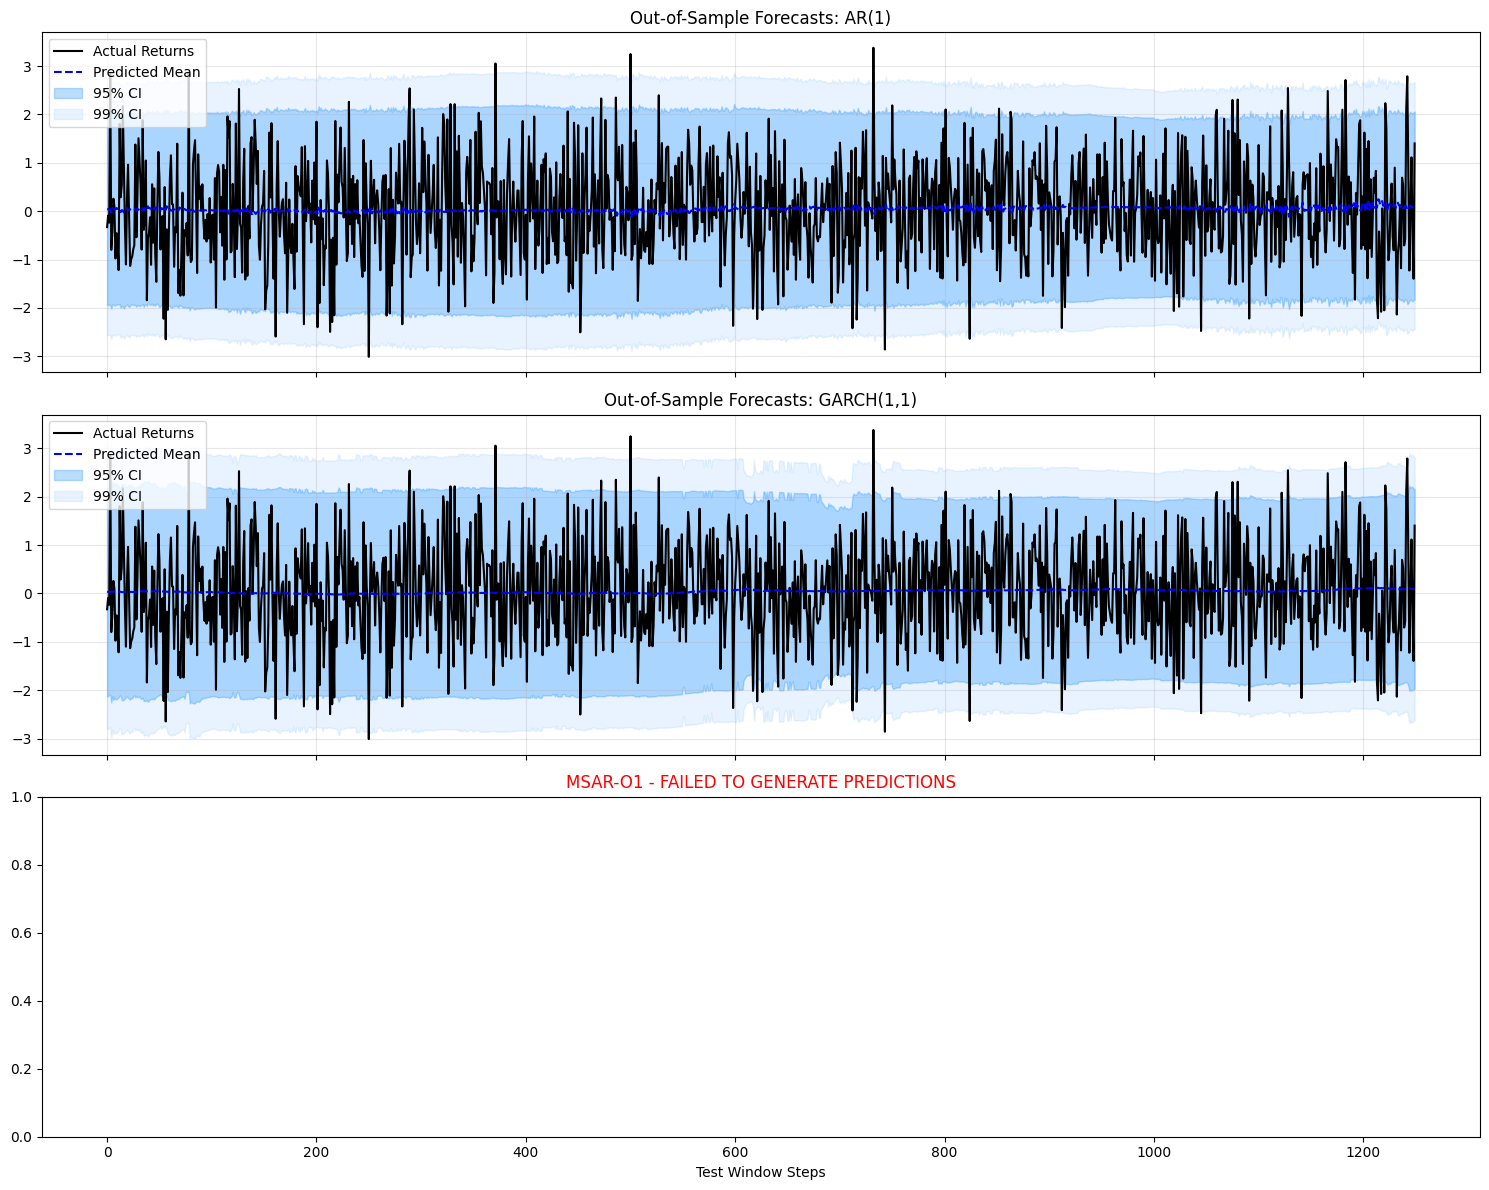

In [9]:
# 1. Get the exact Z-scores for 95% and 99% confidence
z_95 = stats.norm.ppf(0.975) # ~1.96
z_99 = stats.norm.ppf(0.995) # ~2.576

# 2. Extract the actual values for the first path of the last scenario run
path_idx = 0
y_true = paths[path_idx][-test_window:]
x_axis = np.arange(len(y_true))

# 3. Setup the plotting grid
fig, axes = plt.subplots(len(sweeps), 1, figsize=(15, 4 * len(sweeps)), sharex=True)
if len(sweeps) == 1: axes = [axes] # Handle edge case if only testing 1 model

# 4. Loop through each model and plot its specific forecasts
for ax, mod in zip(axes, sweeps.keys()):
    # all_results holds the data from the final scenario in the loop
    preds = np.array(all_results[mod][path_idx])
    
    # Safety check in case a model failed entirely on this path
    if len(preds) == 0 or len(preds) != test_window:
        ax.set_title(f"{mod} - FAILED TO GENERATE PREDICTIONS", color='red')
        continue
        
    p_mean = preds[:, 0]
    p_var = preds[:, 1]
    p_std = np.sqrt(p_var)
    
    # Calculate the upper and lower bounds for the intervals
    lower_95, upper_95 = p_mean - z_95 * p_std, p_mean + z_95 * p_std
    lower_99, upper_99 = p_mean - z_99 * p_std, p_mean + z_99 * p_std
    
    # Plot Actuals vs Predicted Mean
    ax.plot(x_axis, y_true, color='black', lw=1.5, label='Actual Returns')
    ax.plot(x_axis, p_mean, color='blue', ls='--', lw=1.5, label='Predicted Mean')
    
    # Fill the 95% and 99% Confidence Intervals
    ax.fill_between(x_axis, lower_95, upper_95, color='dodgerblue', alpha=0.3, label='95% CI')
    ax.fill_between(x_axis, lower_99, upper_99, color='dodgerblue', alpha=0.1, label='99% CI')
    
    ax.set_title(f"Out-of-Sample Forecasts: {mod}")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.xlabel("Test Window Steps")
plt.tight_layout()
plt.show()